In [1]:
import matplotlib.pyplot as plt
from utils.util_metrics import *
from utils.util_draw import *
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import json
import glob
import natsort as ns
import seaborn as sns
print(plt.style.available)
import utils.ai_plotting as aiplt
aiplt.aingura_plot_style(grid_color='white', plt_style='seaborn-v0_8-white', font_size=17)



['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


#### Add Noise

,noise,model,simu,rmse,rmae,Ratio Test
0,0.0,1.SPBN,simu1,0.000000,0.000000,1.000000
1,0.0,1.SPBN,simu4,0.000000,0.000000,1.000000
2,0.1,1.SPBN,simu1,0.000000,0.000000,1.000000
3,0.1,1.SPBN,simu4,0.000000,0.000000,1.000000
4,0.2,1.SPBN,simu1,0.000000,0.000000,1.000000
5,0.2,1.SPBN,simu4,0.000000,0.000000,1.000000
6,0.3,1.SPBN,simu1,0.000000,0.000000,1.000000
7,0.3,1.SPBN,simu4,0.000000,0.000000,1.000000
8,0.0,2.B-SPBN-Simple,simu1,0.043089,0.156643,1.265433
9,0.0,2.B-SPBN-Simple,simu4,0.023452,0.047650,4.809004


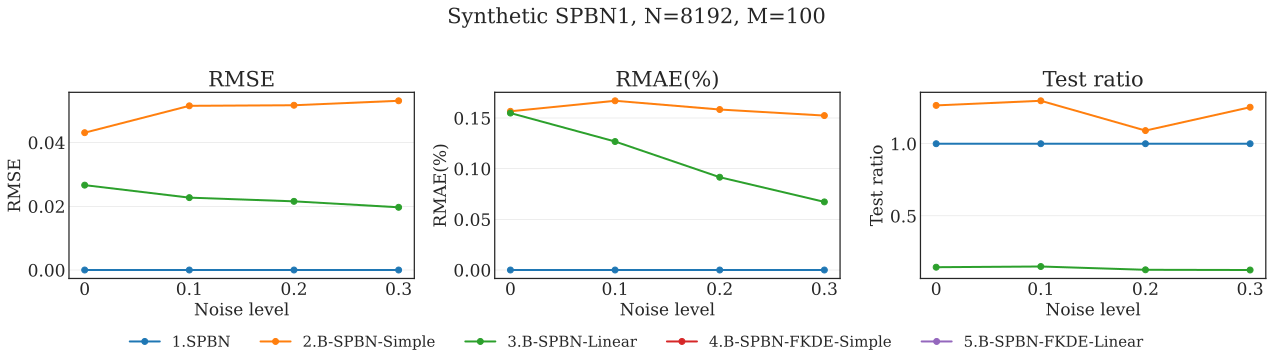

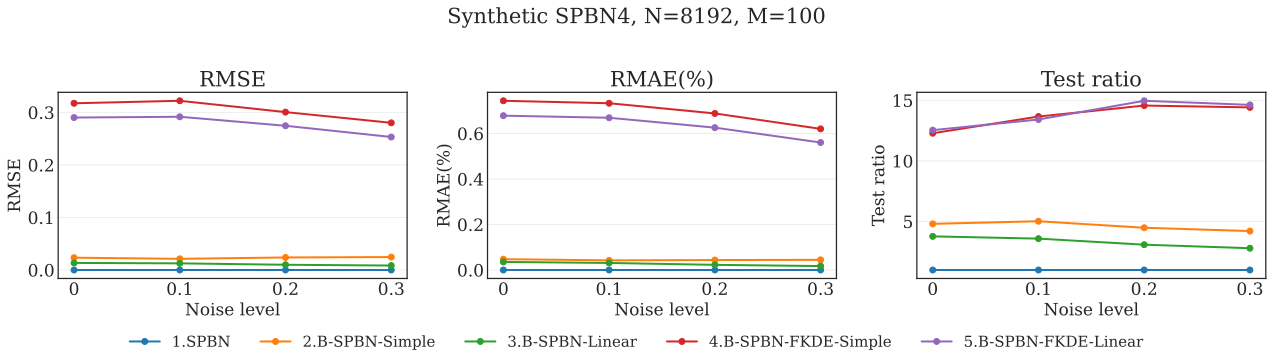

In [37]:
import os
import re
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

noise_dir = 'results/exp_simu/Mfix_sameDAG_noise'
sample_size = '8192'
noise_files = sorted(glob.glob(f'{noise_dir}/simu_all_100_*.json'))

bspbn_models = [
    '1.SPBN',
    '2.B-SPBN-Simple',
    '3.B-SPBN-Linear',
    '4.B-SPBN-FKDE-Simple',
    '5.B-SPBN-FKDE-Linear',
]


rows = []
for path in noise_files:
    noise = float(os.path.basename(path).split('_')[-1][:-5])
    with open(path, 'r') as f:
        payload = json.load(f)
    for model_name in bspbn_models:
        for simulation_key in ['simu1', 'simu4']:
            metrics = payload[model_name][sample_size][simulation_key]['dataframe']
         
            rows.append({
                'noise': noise,
                'model': model_name,
                'simu': simulation_key,
                'rmse': float(metrics['rmse'][0]),
                'rmae': float(metrics['rmae'][0]),
                'Ratio Test': float(metrics['test_REF'][0] / metrics['test'][0]),
            })

noise_df_simus = pd.DataFrame(rows).sort_values(['model', 'noise']).reset_index(drop=True)
display(noise_df_simus)

for simulation_key in ['simu1', 'simu4']:
    noise_df = noise_df_simus[noise_df_simus['simu'] == simulation_key]
    noise_df = noise_df[noise_df['rmse'] > -1 ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True)
    metric_specs = [
        ('rmse', 'RMSE'),
        ('rmae', 'RMAE(%)'),
        ('Ratio Test', 'Test ratio'),
    ]

    for ax, (col, title) in zip(axes, metric_specs):
        for model_name in bspbn_models:
            model_df = noise_df[noise_df['model'] == model_name]
            ax.plot(model_df['noise'], model_df[col], marker='o', linewidth=2, label=model_name)
        ax.set_title(title)
        ax.set_xlabel('Noise level')
        ax.set_ylabel(title)
        ax.grid(axis='y', linestyle='-', color='gray', alpha=0.35)
        ax.set_xticks(sorted(noise_df['noise'].unique()))
        ax.set_xticklabels([f'{x:g}' for x in sorted(noise_df['noise'].unique())])

    legend_handles = [
        Line2D([0], [0], color=ax.lines[i].get_color(), marker='o', linewidth=2, label=bspbn_models[i])
        for i in range(len(bspbn_models))
    ]

    fig.suptitle(f'Synthetic SPBN{simulation_key[-1]}, N=8192, M=100', y=1.02)
    fig.legend(handles=legend_handles, loc='lower center', ncol=len(bspbn_models), bbox_to_anchor=(0.5, -0.08))
    fig.tight_layout()
    plt.show()

#### Compare to other density estimation techniques

In [1]:
from scipy.stats import norm
import pybnesian as pbn
import numpy as np
import time
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
import pandas as pd
from utils.util_syntethic import *

def calculate_true_density3(df):
    densities = []
    for _, row in df.iterrows():
        # Extraemos los valores de las 8 variables
        a, b, c, d, e, f, g, h = row[['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']]
        
        # Calculamos la PDF condicional de cada nodo según el proceso generativo
        # scale = desviación típica = la base de los np.array([...])**2
        
        p_a = 0.5 * norm.pdf(a, loc=4, scale=2) + 0.5 * norm.pdf(a, loc=1, scale=1)
        p_b = norm.pdf(b, loc=a*0.5, scale=2)
        
        p_c = norm.pdf(c, loc=b*2, scale=1.5)
        p_d = 0.5 * norm.pdf(d, loc=b-1, scale=1) + 0.5 * norm.pdf(d, loc=10, scale=1.5)
        
        p_e = 0.5 * norm.pdf(e, loc=d*2, scale=1.5) + 0.5 * norm.pdf(e, loc=3, scale=1)
        p_f = 0.6 * norm.pdf(f, loc=d*1.5, scale=1.5) + 0.4 * norm.pdf(f, loc=0, scale=1)
        
        p_g = norm.pdf(g, loc=c*0.3+5, scale=1)
        p_h = 0.5 * norm.pdf(h, loc=c*0.5, scale=1) + 0.5 * norm.pdf(h, loc=10, scale=1)
        
        # La probabilidad conjunta es el producto de las densidades condicionales
        joint_pdf = p_a * p_b * p_c * p_d * p_e * p_f * p_g * p_h
        densities.append(joint_pdf)
        
    return np.array(densities)

In [6]:


data = pd.read_csv("public_datasets/uci_ready/3_individual_household_electric_power_consumption.csv")
    
train = data.sample(8192, random_state=42)
test = data.drop(train.index).sample(2048, random_state=42)
train = generate_data(3, 8192, seed=0)
test = generate_data(3, 2048, seed=255)
true_density_test = np.log(calculate_true_density3(test))
print(np.sum(true_density_test))
n_components_range = range(1, 7)
best_gmm = None
best_bic = np.inf

start_time = time.time()
for k in n_components_range:
    # Búsqueda del modelo óptimo
    gmm_temp = GaussianMixture(n_components=k, covariance_type='full',reg_covar=1e-3, random_state=42)
    gmm_temp.fit(train)
    bic_score = gmm_temp.bic(train)
    
    if bic_score < best_bic:
        best_bic = bic_score
        best_gmm = gmm_temp

gmm_log_likelihoods = best_gmm.score_samples(test) 
gmm_time = time.time() - start_time
print(f"Best GMM: {best_gmm.n_components} components")
gmm_sll = np.sum(gmm_log_likelihoods)
rmse_gmm = np.sqrt(np.mean(gmm_log_likelihoods - true_density_test) ** 2)
rmae_gmm = np.mean(np.abs(gmm_log_likelihoods - true_density_test) / true_density_test) * 100

kde = KernelDensity(kernel='gaussian')
start_time = time.time()
kde.fit(train)
kde_log_likelihoods = kde.score_samples(test)
kde_time = time.time() - start_time
kde_sll = np.sum(kde_log_likelihoods)
rmse_kde = np.sqrt(np.mean(kde_log_likelihoods - true_density_test) ** 2)
rmae_kde = np.mean(np.abs(kde_log_likelihoods - true_density_test) / true_density_test) * 100

model = pbn.BinnedSPBN(nodes=train.columns)
pool = pbn.OperatorPool([pbn.ArcOperatorSet(), pbn.ChangeNodeTypeSet()])
score = pbn.ValidatedLikelihoodFT(train, k=5, grid=80)
scorefft = pbn.ValidatedLikelihoodFT(train, k=5, grid=80, use_fft=True)

start_time = time.time()
bspbn = pbn.GreedyHillClimbing().estimate(pool, score, model, patience=3, max_indegree=1)
bspbn.fit(train, grid=80)
bspbn_logl = bspbn.logl(test)
bpsnbn_time = time.time() - start_time
rmse_bspbn = np.sqrt(np.mean(bspbn_logl - true_density_test) ** 2)
rmae_bspbn = np.mean(np.abs(bspbn_logl - true_density_test) / true_density_test) * 100

start_time = time.time()
bspbnfft = pbn.GreedyHillClimbing().estimate(pool, scorefft, model, patience=3, max_indegree=1)
bspbnfft.fit(train, grid=80, use_fft=True)
bspbnfft_logl = bspbnfft.logl(test)
bspbnfft_time = time.time() - start_time
rmse_logl = np.sqrt(np.mean(bspbnfft_logl - true_density_test) ** 2)
rmae_logl = np.mean(np.abs(bspbnfft_logl - true_density_test) / true_density_test) * 100  

data = {
    'GMM': {
        'slogl': gmm_sll,
        'rmse': rmse_gmm,
        'rmae': rmae_gmm,
        'time': gmm_time,
        
    },
    'KDE': {
        'slogl': kde_sll,
        'rmse': rmse_kde,
        'rmae': rmae_kde,
        'time': kde_time,
    },
    'B-SPBN': {
        'slogl': np.sum(bspbn_logl),
        'rmse': rmse_bspbn,
        'rmae': rmae_bspbn,
        'time': bpsnbn_time,
    },
    'B-SPBN-FFT': {
        'slogl': np.sum(bspbnfft_logl),
        'rmse': rmse_logl,
        'rmae': rmae_logl,
        'time': bspbnfft_time,
    },
}
results_df = pd.DataFrame(data).T
results_df

-33486.28553985647
Best GMM: 6 components


,slogl,rmse,rmae,time
GMM,-35904.430211,1.180735,-8.656839,0.327925
KDE,-35682.813057,1.072523,-8.419549,0.624193
B-SPBN,-34590.079283,0.538962,-5.362688,44.164309
B-SPBN-FFT,-34616.530808,0.551878,-5.523801,35.208440
